# Assignment 1 2AMM10 2025-2026

## Group: YapGPT
### Member 1: Nicole Ganin
### Member 2: Sybren Postma
### Member 3: Vivan Victoria

In [ ]:
!pip install "kagglehub==0.4.3"

In [7]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict


## Task 1 

Dataset and visualization

In [10]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict


CACHE_FILE = Path.home() / ".apple_dataset_path.txt"

def get_dataset_path():
    """
    Verfies whether the dataset exists locally already, if not downloads it from kaggle.
    """
    if CACHE_FILE.exists():
        return Path(CACHE_FILE.read_text().strip())
    path = kagglehub.dataset_download("moltean/fruits")
    CACHE_FILE.write_text(str(path))
    return Path(path)


class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = get_dataset_path() # <--
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else: 
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([item_dd, frame_slider, output]))

100%|██████████| 5.99G/5.99G [02:26<00:00, 44.1MB/s]

Extracting files...


In [8]:
# Some more packages and modules
from torchvision import transforms
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from collections import defaultdict
import random
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [11]:
transform = transforms.Compose([transforms.Resize((100,100)), transforms.ToTensor(),]) # Tensor is easy to work with for torch and NN
train_data = AppleDataset(subset="train",transform=transform)
test_data = AppleDataset(subset="test",transform=transform)
support_new_data = AppleDataset(subset="train",transform=transform,class_subset="new")
test_new_data = AppleDataset(subset="test",transform=transform,class_subset="new")

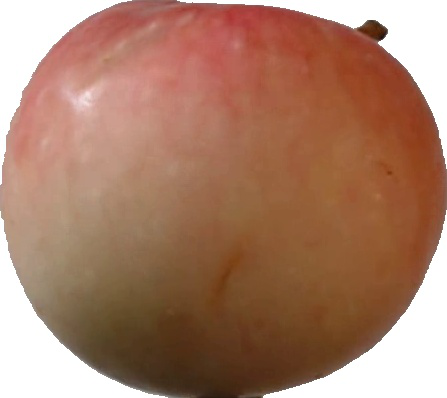

In [65]:
# Visualising the dataset
dataset[10][0]

An appropriate neural network to learn embeddings from this dataset, could be Convolutional Neural Network

### 2
#### Triplet Loss
Loss = max(0, d(a,p) − d(a,n) + margin)

where
a = anchor
p = same item
n = different item

In [12]:
# Creating a triplet object
# For each anchor, picks a different image of the same class as positive
# And a random image from a different class as negative
class TripletAppleDataset(Dataset):
    def __init__(self, base_dataset):
        self.dataset = base_dataset
        self.label_to_indices = defaultdict(list)
        for idx in range(len(base_dataset)):
            _, label = base_dataset[idx]
            self.label_to_indices[label].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        anchor_img, anchor_label = self.dataset[idx]

        pos_idx = idx
        while pos_idx == idx:
            pos_idx = random.choice(self.label_to_indices[anchor_label])

        neg_label = anchor_label
        while neg_label == anchor_label:
            neg_label = random.choice(self.labels)
        neg_idx = random.choice(self.label_to_indices[neg_label])

        pos_img, _ = self.dataset[pos_idx]
        neg_img, _ = self.dataset[neg_idx]

        return anchor_img, pos_img, neg_img

In [14]:
triplet_train = TripletAppleDataset(train_data)
train_loader = DataLoader(triplet_train, batch_size=64, shuffle=True)

### 3 Model training and evaluation

In [13]:
# A Convolutional neural network with three convolutional blocks
# to extract spatial features, then flatten to a fixed-size embedding.
# Finally, L2 normalization maintains embeddings on the unit sphere, which complements triplet loss.
class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*12*12,256),
            nn.ReLU(),
            nn.Linear(256,embedding_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        x = F.normalize(x,p=2,dim=1)
        return x

In [18]:
triplet_loss = nn.TripletMarginLoss(margin=1.0) # Loss function (torch)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmbeddingNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    model.train()
    running_loss = 0

    for anchor, positive, negative in train_loader:
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
        loss = triplet_loss(model(anchor), model(positive), model(negative))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}: {running_loss/len(train_loader):.4f}")

Epoch 1: 0.1979
Epoch 2: 0.0627
Epoch 3: 0.0275
Epoch 4: 0.0150
Epoch 5: 0.0120
Epoch 6: 0.0079
Epoch 7: 0.0061
Epoch 8: 0.0063
Epoch 9: 0.0039
Epoch 10: 0.0027


In [14]:
def extract_embeddings(dataset, model):
    loader = DataLoader(dataset, batch_size=64)
    embeddings, labels = [], []
    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            embeddings.append(model(imgs.to(device)).cpu())
            labels.extend(lbls)
    return torch.cat(embeddings).numpy(), np.array(labels)

In [20]:
train_embeddings, train_labels = extract_embeddings(train_data, model)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(train_embeddings, train_labels)

test_embeddings, test_labels = extract_embeddings(test_data, model)
print("Seen item accuracy:", accuracy_score(test_labels, knn.predict(test_embeddings)))

KNeighborsClassifier(n_neighbors=1)

In [22]:
support_embeddings, support_labels = extract_embeddings(support_new_data, model)
knn_new = KNeighborsClassifier(n_neighbors=1)
knn_new.fit(support_embeddings, support_labels)

new_test_embeddings, new_test_labels = extract_embeddings(test_new_data, model)
print("Unseen item accuracy:", accuracy_score(new_test_labels, knn_new.predict(new_test_embeddings)))

Unseen item accuracy: 0.9039692701664532


## Task 2

In [15]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = get_dataset_path()
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0]) 

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)
 
        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

family_dd.observe(update_items, names="value")
item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

In [16]:
train_data = GardenDataset(subset="train", transform=transform)

# scenario 1 
test_data = GardenDataset(subset="test", transform=transform)

# scenario 2 
train_data_family = GardenDataset(subset="train", transform=transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform, class_level="family")

# scenario 3 
support_all_data = GardenDataset(subset="train", transform=transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=transform, item_subset="new")

# scenario 4 
support_all_data_family = GardenDataset(subset="train", transform=transform, family_subset="all",class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=transform, family_subset="new",class_level="family")

# your code here

In [18]:
triplet_garden = TripletAppleDataset(train_data)
train_loader = DataLoader(triplet_garden, batch_size=64, shuffle=True)

In [28]:
# Scenario 1 - seen items
train_emb, train_lbl = extract_embeddings(train_data, model)
test_emb, test_lbl = extract_embeddings(test_data, model)
knn.fit(train_emb, train_lbl)
print("Scenario 1:", accuracy_score(test_lbl, knn.predict(test_emb)))

0.9998555226468251


In [29]:
# Scenario 2 — seen families
train_emb, train_lbl = extract_embeddings(train_data_family, model)
test_emb, test_lbl = extract_embeddings(test_data_family, model)
knn.fit(train_emb, train_lbl)
print("Scenario 2:", accuracy_score(test_lbl, knn.predict(test_emb)))

0.9998555226468251


In [30]:
# Scenario 3 — unseen items
train_emb, train_lbl = extract_embeddings(support_all_data, model)
test_emb, test_lbl = extract_embeddings(test_new_data, model)
knn.fit(train_emb, train_lbl)
print("Scenario 3:", accuracy_score(test_lbl, knn.predict(test_emb)))

1.0


In [31]:
# Scenario 4 — unseen families (completely new fruit types)
train_emb, train_lbl = extract_embeddings(support_all_data_family, model)
test_emb, test_lbl = extract_embeddings(test_new_data_family, model)
knn.fit(train_emb, train_lbl)
print("Scenario 4:", accuracy_score(test_lbl, knn.predict(test_emb)))

0.9995280792826805


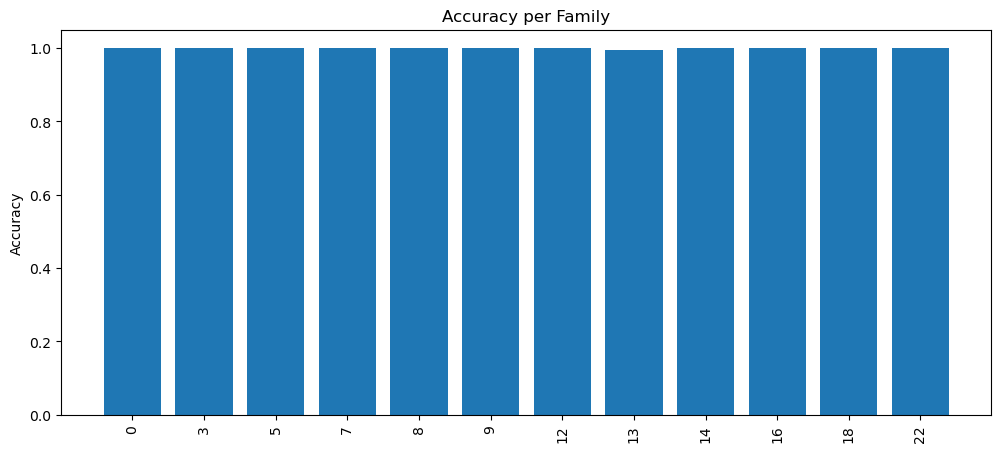

In [32]:
# Visualising per-family accuracies
family_correct = defaultdict(int)
family_total = defaultdict(int)
for true, pred in zip(test_lbl, knn.predict(test_emb)):
    family_total[true] += 1
    if true == pred:
        family_correct[true] += 1

families = list(family_total.keys())
accs = [family_correct[f] / family_total[f] for f in families]

plt.figure(figsize=(12, 5))
plt.bar([str(f) for f in families], accs)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.title("Accuracy per Family")
plt.tight_layout()
plt.show()

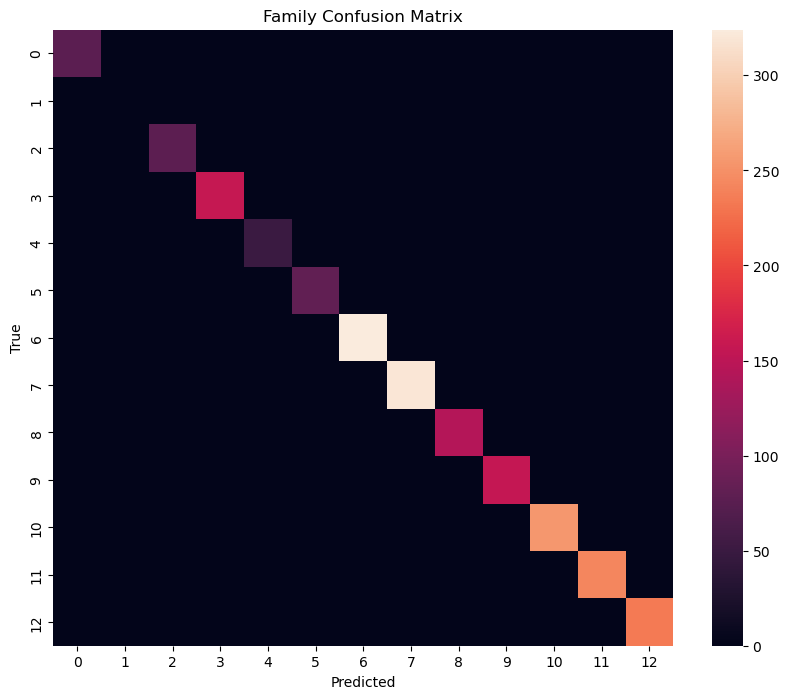

In [33]:
cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm)
plt.title("Family Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Task 3

In [19]:
train_data_both = GardenDataset(class_level="both",transform=transform,subset="train",family_subset="main",item_subset="main")

test_data_both = GardenDataset(class_level="both",transform=transform,subset="test",family_subset="main",item_subset="main")

In [20]:
from torch.utils.data import Dataset

class HierarchicalTripletDataset(Dataset):
    def __init__(self, base_dataset):
        self.dataset = base_dataset
        self.item_to_indices = defaultdict(list)
        self.family_to_indices = defaultdict(list)
        for idx in range(len(base_dataset)):
            _, fam, item = base_dataset[idx]
            self.item_to_indices[item].append(idx)
            self.family_to_indices[fam].append(idx)
        self.items = list(self.item_to_indices.keys())
        self.families = list(self.family_to_indices.keys())

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        anchor_img, anchor_fam, anchor_item = self.dataset[idx]

        # same item but different image
        pos_item_idx = idx
        while pos_item_idx == idx:
            pos_item_idx = random.choice(self.item_to_indices[anchor_item])
        pos_item_img, _, _ = self.dataset[pos_item_idx]

        # same family but different item
        while True:
            pos_fam_idx = random.choice(self.family_to_indices[anchor_fam])
            _, _, item = self.dataset[pos_fam_idx]
            if item != anchor_item:
                break
        pos_fam_img, _, _ = self.dataset[pos_fam_idx]

        # different family entirely
        neg_fam = anchor_fam
        while neg_fam == anchor_fam:
            neg_fam = random.choice(self.families)
        neg_img, _, _ = self.dataset[random.choice(self.family_to_indices[neg_fam])]

        return anchor_img, pos_item_img, pos_fam_img, neg_img

In [38]:
train_data = GardenDataset(transform=transform, class_level="both", subset="train", family_subset="main", item_subset="main")

triplet_train = HierarchicalTripletDataset(train_data)
train_loader = DataLoader(triplet_train, batch_size=64, shuffle=True)

# Two margins but stricter for same item compared to same family
family_loss_fn = nn.TripletMarginLoss(margin=0.5)
item_loss_fn = nn.TripletMarginLoss(margin=1.0)

model = EmbeddingNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(2):
    model.train()
    running_loss = 0
    for anchor, pos_item, pos_fam, negative in train_loader:
        anchor, pos_item, pos_fam, negative = (
            anchor.to(device), pos_item.to(device), pos_fam.to(device), negative.to(device)
        )
        optimizer.zero_grad()

        a_emb = model(anchor)
        item_loss = item_loss_fn(a_emb, model(pos_item), model(negative))
        family_loss = family_loss_fn(a_emb, model(pos_fam), model(negative))
        loss = item_loss + 0.5 * family_loss

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}: {running_loss / len(train_loader):.4f}")

Epoch 1: 0.1532
Epoch 2: 0.0114


In [21]:
# Helper function in order to use knn classifier as it expects (img, label) pairs not triplets with family
class EmbeddingDataset(Dataset):
    def __init__(self, base, label_type="item"):
        self.base = base
        self.label_type = label_type

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]
        img = item[0]
        if len(item) == 3:
            family, item_label = item[1], item[2]
            return img, int(item_label if self.label_type == "item" else family)
        return img, int(item[1])

In [41]:
# Scenario 1
train_emb, train_lbl = extract_embeddings(EmbeddingDataset(train_data, label_type="item"), model)
test_emb, test_lbl = extract_embeddings(EmbeddingDataset(test_data_both, label_type="item"), model)
knn.fit(train_emb, train_lbl)
print("Scenario 1:", accuracy_score(test_lbl, knn.predict(test_emb)))

1.0


In [56]:
# Scenario 2
train_emb, train_lbl = extract_embeddings(train_data_family, model)
test_emb, test_lbl = extract_embeddings(test_data_family, model)
knn.fit(train_emb, train_lbl)
print("Scenario 2:", accuracy_score(test_lbl, knn.predict(test_emb)))

1.0


In [61]:
# Scenario 3
train_emb, train_lbl = extract_embeddings(support_all_data, model)
test_emb, test_lbl = extract_embeddings(test_new_data, model)
knn.fit(train_emb, train_lbl)
print("Scenario 3:", accuracy_score(test_lbl, knn.predict(test_emb)))

0.9994926433282597


In [63]:
# Scenario 4
train_emb, train_lbl = extract_embeddings(support_all_data_family, model)
test_emb, test_lbl = extract_embeddings(test_new_data_family, model)
knn.fit(train_emb, train_lbl)
print("Scenario 4:", accuracy_score(test_lbl, knn.predict(test_emb)))

1.0


## Task 4

In [33]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).
    
    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    transform = transforms.Compose([
        transforms.Resize((100, 100)),
        transforms.ToTensor(),
        BlackoutPixels(fraction=fraction),
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here


### 4.1 Feature embedding model 

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmbeddingNet().to(device)
model.load_state_dict(torch.load("model_task3.pkl", map_location=device, weights_only=True))
model.eval()

EmbeddingNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [28]:
normal_train = GardenDataset(subset="train", transform=transform, family_subset="main", item_subset="main")

normal_test = GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

train_emb, _ = extract_embeddings(normal_train, model)
test_emb, _ = extract_embeddings(normal_test, model)

from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(n_neighbors=1)
nn_model.fit(train_emb)

normal_scores = nn_model.kneighbors(test_emb, return_distance=True)[0].min(axis=1)
threshold = np.percentile(normal_scores, 90)
print("Threshold:", threshold)
print("False positive rate:", np.mean(normal_scores > threshold))

Threshold: 0.020408038794994355
False positive rate: 0.10005056707361121


In [34]:
for frac in [0.01, 0.05, 0.10]:
    anomaly_data = get_anomaly_dataset(frac)
    anomaly_emb, _ = extract_embeddings(anomaly_data, model)
    anomaly_scores = nn_model.kneighbors(anomaly_emb, return_distance=True)[0].min(axis=1)
    detection_rate = np.mean(anomaly_scores > threshold)

    print(f"{int(frac * 100)}% black pixels: {detection_rate * 100:.2f}% detected")

1% black pixels: 84.61% detected
5% black pixels: 99.95% detected
10% black pixels: 100.00% detected


### 4.2 Autoencoder

In [35]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x[:, :, :100, :100]

In [ ]:
# Train the autoencoder on normal data

auto_e = Autoencoder().to(device)
optimizer = torch.optim.Adam(auto_e.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loader = DataLoader(normal_train, batch_size=16, shuffle=True)
prev_loss = None

for epoch in range(10):
    auto_e.train()
    total_loss = 0

    for imgs, _ in loader:
        imgs = imgs.to(device)

        recon = auto_e(imgs)
        loss = loss_fn(recon, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)

    print(f"Epoch {epoch+1}: {avg_loss:.4f}")
    
    if prev_loss is not None and avg_loss > prev_loss:
        print("Validation loss increased, stopping training.")
        break
    prev_loss = avg_loss    

Epoch 1: 0.0039
Epoch 2: 0.0008
Epoch 3: 0.0005
Epoch 4: 0.0004
Epoch 5: 0.0003
Epoch 6: 0.0003
Epoch 7: 0.0002
Epoch 8: 0.0002
Epoch 9: 0.0002
Epoch 10: 0.0002


In [43]:
# Compute reconstruction scores for normal test data
def reconstruction_scores(dataset, auto_e):
    loader = DataLoader(dataset, batch_size=16)
    scores = []

    auto_e.eval()
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            recon = auto_e(imgs)

            batch_scores = ((imgs - recon) ** 2).mean(dim=(1, 2, 3))
            scores.extend(batch_scores.cpu().numpy())

    return np.array(scores)

In [ ]:
# Compute reconstruction scores for normal test data to set threshold

normal_scores = reconstruction_scores(normal_test, auto_e)
threshold = np.percentile(normal_scores, 90)

print("False positive rate:", np.mean(normal_scores > threshold))

for frac in [0.01, 0.05, 0.10]:
    anomaly_data = get_anomaly_dataset(frac)
    anomaly_scores = reconstruction_scores(anomaly_data, auto_e)

    detection_rate = np.mean(anomaly_scores > threshold)
    print(f"{int(frac * 100)}% black pixels: {detection_rate * 100:.2f}% detected")

False positive rate: 0.10005056707361121
1% black pixels: 100.00% detected
5% black pixels: 100.00% detected
10% black pixels: 100.00% detected


In [45]:
# Save models
torch.save(auto_e.state_dict(), "autoencoder_task3.pkl")